# Salary Prediction — EDA & Model Training
**AIE Program | Week 1 Assignment**  
Dataset: Data Science Job Salaries (Kaggle)

## Section 1 — Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.size': 10,
})
BLUE, CORAL, TEAL = '#4C72B0', '#DD8452', '#55A868'

os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)
print('Setup complete.')

Setup complete.


## Section 2 — Load Data

In [3]:
df = pd.read_csv('ds_salaries.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (607, 12)


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


## Section 3 — Initial Exploration

In [4]:
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Descriptive Statistics ===')
df.describe()

=== Data Types ===
Unnamed: 0             int64
work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

=== Descriptive Statistics ===


,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [5]:
# ── Null check ───────────────────────────────────────────────────────────
null_counts = df.isnull().sum()
print('=== Null Values per Column ===')
print(null_counts)
if null_counts.sum() == 0:
    print('\n✅ No null values found — no imputation needed.')
else:
    print(f'\n⚠️  Total nulls: {null_counts.sum()} — imputation required.')

=== Null Values per Column ===
Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

✅ No null values found — no imputation needed.


In [9]:
print(df.duplicated().sum(), "duplicates")

0 duplicates


In [6]:
# ── Unique value counts ──────────────────────────────────────────────────
print('=== Unique Values per Column ===')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()} unique values')

=== Unique Values per Column ===
  Unnamed: 0: 607 unique values
  work_year: 3 unique values
  experience_level: 4 unique values
  employment_type: 4 unique values
  job_title: 50 unique values
  salary: 272 unique values
  salary_currency: 17 unique values
  salary_in_usd: 369 unique values
  employee_residence: 57 unique values
  remote_ratio: 3 unique values
  company_location: 50 unique values
  company_size: 3 unique values


## Section 4 — Outlier Analysis

We inspect `salary_in_usd` for extreme outliers using the IQR method.  
Our chosen strategy: **cap at the 99th percentile** before applying log-transform.  
This is softer than removal (keeps all rows) and the log-transform further compresses the tail.

In [10]:
target = 'salary_in_usd'

Q1 = df[target].quantile(0.25)
Q3 = df[target].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df[(df[target] < lower_fence) | (df[target] > upper_fence)]
print(f'IQR Bounds  →  lower: ${lower_fence:,.0f}   upper: ${upper_fence:,.0f}')
print(f'Outliers detected: {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)')
print()
print('Top outliers:')
print(outliers[['job_title', 'experience_level', 'company_location', target]]
      .sort_values(target, ascending=False)
      .head(10)
      .to_string(index=False))

IQR Bounds  →  lower: $-68,185   upper: $280,911
Outliers detected: 10 rows (1.6%)

Top outliers:
                         job_title experience_level company_location  salary_in_usd
           Principal Data Engineer               EX               US         600000
                Research Scientist               MI               US         450000
            Financial Data Analyst               MI               US         450000
Applied Machine Learning Scientist               MI               US         423000
          Principal Data Scientist               EX               US         416000
                    Data Scientist               SE               US         412000
               Data Analytics Lead               SE               US         405000
            Applied Data Scientist               SE               US         380000
          Director of Data Science               EX               US         325000
                     Data Engineer               EX           

In [11]:
# ── Cap at 99th percentile ───────────────────────────────────────────────
cap_99 = df[target].quantile(0.99)
print(f'99th percentile cap: ${cap_99:,.0f}')
print(f'Max before cap:      ${df[target].max():,.0f}')

df[target] = df[target].clip(upper=cap_99)
print(f'Max after cap:       ${df[target].max():,.0f}')
print(f'\n✅ {(df[target] == cap_99).sum()} rows were capped.')

99th percentile cap: $403,500
Max before cap:      $600,000
Max after cap:       $403,500

✅ 0 rows were capped.


## Section 5 — Feature Engineering

Steps:
1. Drop irrelevant columns (`Unnamed: 0`, `salary`, `salary_currency`)
2. Bucket `job_title` into 5 broad categories
3. Engineer `is_international_remote` from `company_location` vs `employee_residence`
4. Drop `employee_residence` and original `job_title`

In [12]:
# ── Drop irrelevant columns ───────────────────────────────────────────────
df.drop(columns=['Unnamed: 0', 'salary', 'salary_currency'], inplace=True)
print('Columns after dropping irrelevant ones:')
print(df.columns.tolist())

Columns after dropping irrelevant ones:
['work_year', 'experience_level', 'employment_type', 'job_title', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']


In [13]:
# ── Job title bucketing ───────────────────────────────────────────────────
JOB_TITLE_MAP = {
    # Data Scientist bucket
    'Data Scientist': 'Data Scientist',
    'Applied Data Scientist': 'Data Scientist',
    'Principal Data Scientist': 'Data Scientist',
    'Staff Data Scientist': 'Data Scientist',
    'Lead Data Scientist': 'Data Scientist',
    'Data Science Engineer': 'Data Scientist',
    'Head of Data Science': 'Data Scientist',
    'Data Science Consultant': 'Data Scientist',
    'Data Science Manager': 'Data Scientist',
    'Director of Data Science': 'Data Scientist',
    # Data Engineer bucket
    'Data Engineer': 'Data Engineer',
    'Big Data Engineer': 'Data Engineer',
    'Lead Data Engineer': 'Data Engineer',
    'Principal Data Engineer': 'Data Engineer',
    'Cloud Data Engineer': 'Data Engineer',
    'Data Engineering Manager': 'Data Engineer',
    'Director of Data Engineering': 'Data Engineer',
    'Analytics Engineer': 'Data Engineer',
    'Data Analytics Engineer': 'Data Engineer',
    'ETL Developer': 'Data Engineer',
    # Data Analyst bucket
    'Data Analyst': 'Data Analyst',
    'BI Data Analyst': 'Data Analyst',
    'Business Data Analyst': 'Data Analyst',
    'Product Data Analyst': 'Data Analyst',
    'Financial Data Analyst': 'Data Analyst',
    'Finance Data Analyst': 'Data Analyst',
    'Marketing Data Analyst': 'Data Analyst',
    'Lead Data Analyst': 'Data Analyst',
    'Principal Data Analyst': 'Data Analyst',
    'Data Analytics Lead': 'Data Analyst',
    'Data Analytics Manager': 'Data Analyst',
    # ML Engineer bucket
    'Machine Learning Engineer': 'ML Engineer',
    'ML Engineer': 'ML Engineer',
    'Machine Learning Developer': 'ML Engineer',
    'Lead Machine Learning Engineer': 'ML Engineer',
    'Machine Learning Infrastructure Engineer': 'ML Engineer',
    'Head of Machine Learning': 'ML Engineer',
    'Machine Learning Manager': 'ML Engineer',
    'Machine Learning Scientist': 'ML Engineer',
    'Applied Machine Learning Scientist': 'ML Engineer',
    'AI Scientist': 'ML Engineer',
    'NLP Engineer': 'ML Engineer',
    # Research & Specialized bucket
    'Research Scientist': 'Research & Specialized',
    'Computer Vision Engineer': 'Research & Specialized',
    'Computer Vision Software Engineer': 'Research & Specialized',
    '3D Computer Vision Researcher': 'Research & Specialized',
    'Data Architect': 'Research & Specialized',
    'Big Data Architect': 'Research & Specialized',
    'Data Specialist': 'Research & Specialized',
    'Head of Data': 'Research & Specialized',
}

df['job_title_bucket'] = df['job_title'].map(JOB_TITLE_MAP)
unmapped = df['job_title_bucket'].isnull().sum()
print(f'Unmapped titles: {unmapped}')
if unmapped > 0:
    print(df[df['job_title_bucket'].isnull()]['job_title'].unique())
print()
print('Bucket counts:')
print(df['job_title_bucket'].value_counts())

Unmapped titles: 0

Bucket counts:
job_title_bucket
Data Scientist            192
Data Engineer             168
Data Analyst              127
ML Engineer                76
Research & Specialized     44
Name: count, dtype: int64


In [14]:
# ── International remote feature ─────────────────────────────────────────
df['is_international_remote'] = (
    (df['company_location'] != df['employee_residence']).astype(int)
)
print(f'International remote workers: {df["is_international_remote"].sum()} '
      f'({df["is_international_remote"].mean()*100:.1f}% of dataset)')

# ── Drop redundant columns ────────────────────────────────────────────────
df.drop(columns=['employee_residence', 'job_title'], inplace=True)
print('\nFinal columns:')
print(df.columns.tolist())

International remote workers: 51 (8.4% of dataset)

Final columns:
['work_year', 'experience_level', 'employment_type', 'salary_in_usd', 'remote_ratio', 'company_location', 'company_size', 'job_title_bucket', 'is_international_remote']


## Section 6 — EDA Visualizations

In [15]:
# ── Helper formatter ─────────────────────────────────────────────────────
def usd_fmt(ax, axis='y'):
    fmt = mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
    if axis == 'y':
        ax.yaxis.set_major_formatter(fmt)
    else:
        ax.xaxis.set_major_formatter(fmt)

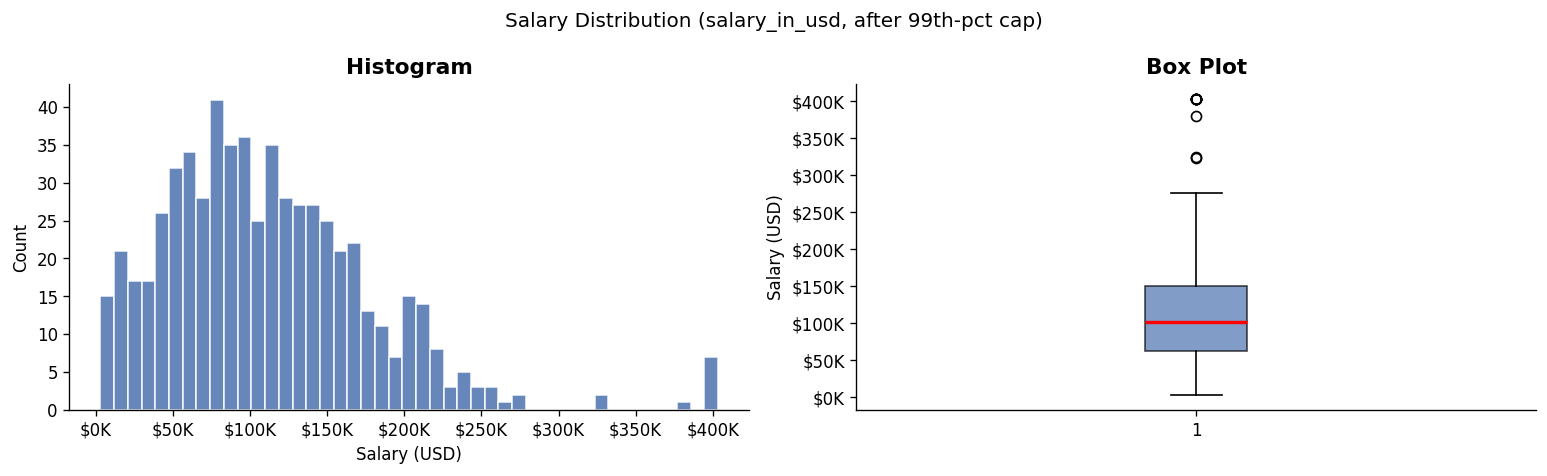

In [16]:
# ── 6.1  Salary distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Salary Distribution (salary_in_usd, after 99th-pct cap)', fontsize=12)

axes[0].hist(df['salary_in_usd'], bins=45, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].set_title('Histogram')
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Count')
usd_fmt(axes[0], 'x')

bp = axes[1].boxplot(df['salary_in_usd'], vert=True, patch_artist=True,
                     boxprops=dict(facecolor=BLUE, alpha=0.7),
                     medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Salary (USD)')
usd_fmt(axes[1])

plt.tight_layout()
plt.savefig('plots/salary_distribution.png', bbox_inches='tight')
plt.show()

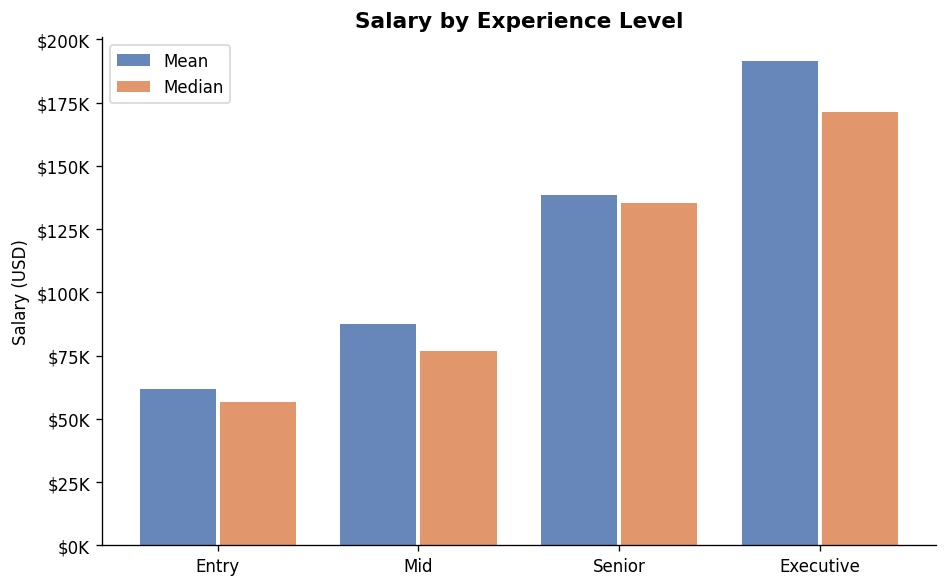

In [17]:
# ── 6.2  Salary by experience level ─────────────────────────────────────
EXP_ORDER  = ['EN', 'MI', 'SE', 'EX']
EXP_LABELS = {'EN': 'Entry', 'MI': 'Mid', 'SE': 'Senior', 'EX': 'Executive'}

exp_stats = (df.groupby('experience_level')['salary_in_usd']
               .agg(['mean', 'median'])
               .reindex(EXP_ORDER))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(EXP_ORDER))
ax.bar(x - 0.2, exp_stats['mean'],   0.38, label='Mean',   color=BLUE,  alpha=0.85)
ax.bar(x + 0.2, exp_stats['median'], 0.38, label='Median', color=CORAL, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([EXP_LABELS[e] for e in EXP_ORDER])
ax.set_title('Salary by Experience Level')
ax.set_ylabel('Salary (USD)')
usd_fmt(ax)
ax.legend()
plt.tight_layout()
plt.savefig('plots/salary_by_experience.png', bbox_inches='tight')
plt.show()

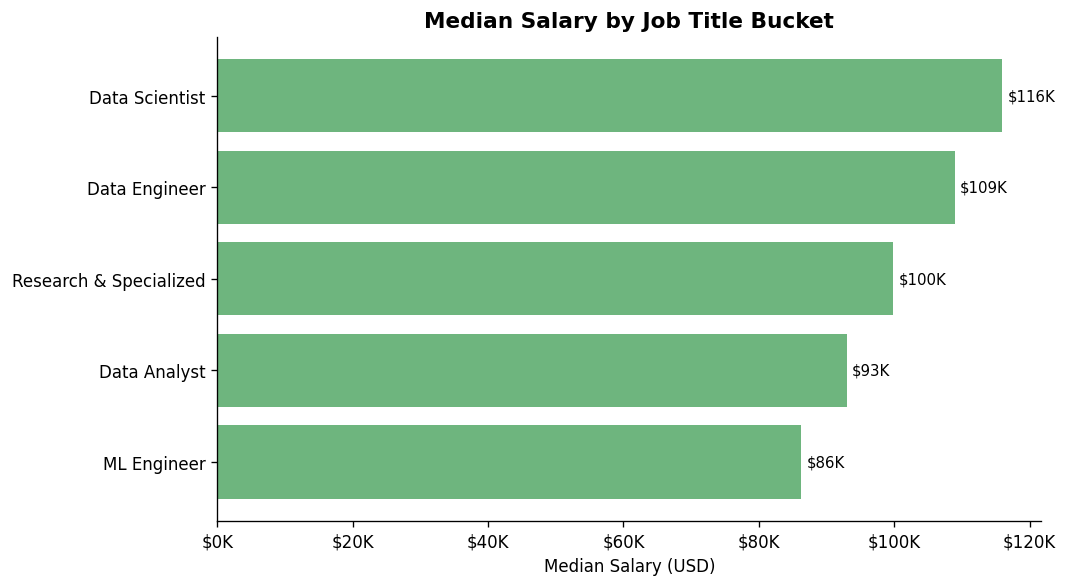

In [18]:
# ── 6.3  Salary by job title bucket ─────────────────────────────────────
jt_median = (df.groupby('job_title_bucket')['salary_in_usd']
               .median()
               .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(jt_median.index, jt_median.values, color=TEAL, alpha=0.85)
ax.set_title('Median Salary by Job Title Bucket')
ax.set_xlabel('Median Salary (USD)')
usd_fmt(ax, 'x')
for bar, val in zip(bars, jt_median.values):
    ax.text(val + 800, bar.get_y() + bar.get_height() / 2,
            f'${val/1000:.0f}K', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plots/salary_by_job_bucket.png', bbox_inches='tight')
plt.show()

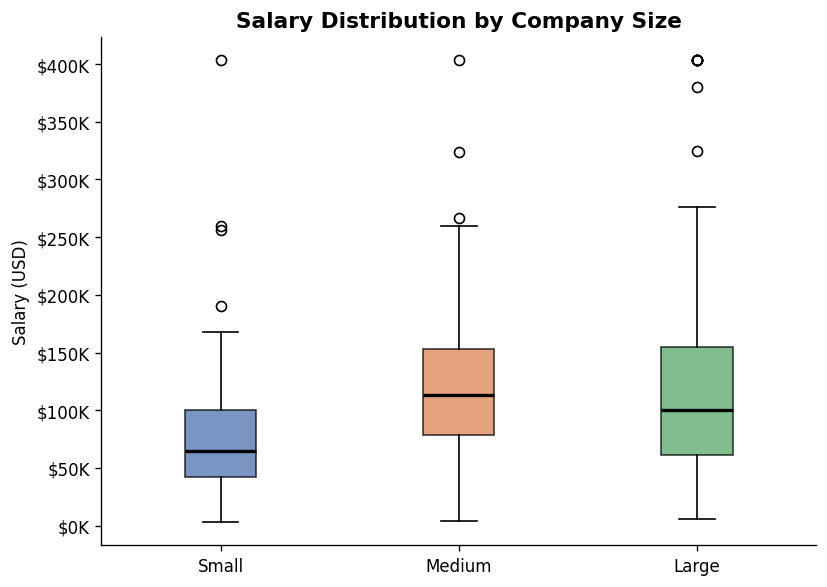

In [19]:
# ── 6.4  Salary by company size ─────────────────────────────────────────
SIZE_ORDER  = ['S', 'M', 'L']
SIZE_LABELS = ['Small', 'Medium', 'Large']

fig, ax = plt.subplots(figsize=(7, 5))
data_by_size = [df[df['company_size'] == s]['salary_in_usd'].values for s in SIZE_ORDER]
bp = ax.boxplot(data_by_size, patch_artist=True, labels=SIZE_LABELS)
for patch, color in zip(bp['boxes'], [BLUE, CORAL, TEAL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for median_line in bp['medians']:
    median_line.set_color('black')
    median_line.set_linewidth(2)
ax.set_title('Salary Distribution by Company Size')
ax.set_ylabel('Salary (USD)')
usd_fmt(ax)
plt.tight_layout()
plt.savefig('plots/salary_by_company_size.png', bbox_inches='tight')
plt.show()

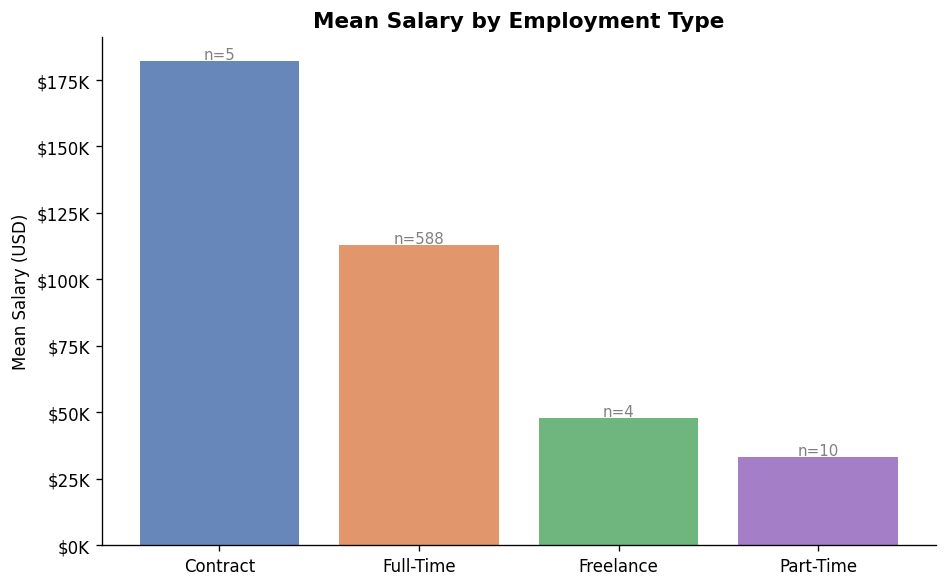

In [20]:
# ── 6.5  Salary by employment type ───────────────────────────────────────
EMP_LABELS = {'FT': 'Full-Time', 'PT': 'Part-Time', 'CT': 'Contract', 'FL': 'Freelance'}

emp_stats = (df.groupby('employment_type')['salary_in_usd']
               .agg(['mean', 'count'])
               .sort_values('mean', ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [EMP_LABELS.get(e, e) for e in emp_stats.index],
    emp_stats['mean'],
    color=[BLUE, CORAL, TEAL, '#9467bd'], alpha=0.85
)
ax.set_title('Mean Salary by Employment Type')
ax.set_ylabel('Mean Salary (USD)')
usd_fmt(ax)
for bar, (_, row) in zip(bars, emp_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 800,
            f'n={int(row["count"])}', ha='center', fontsize=9, color='grey')
plt.tight_layout()
plt.savefig('plots/salary_by_employment_type.png', bbox_inches='tight')
plt.show()

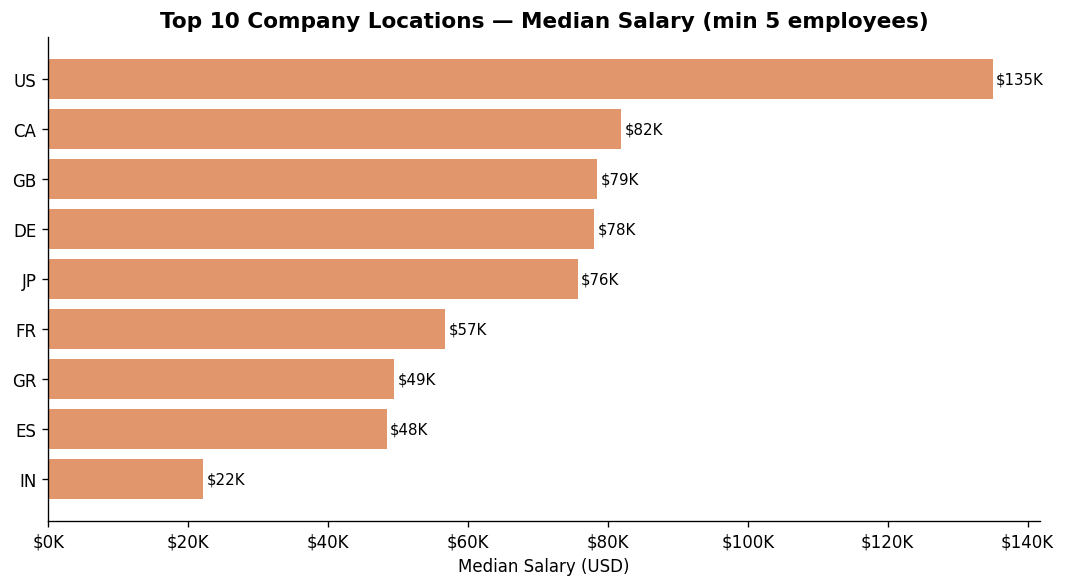

In [21]:
# ── 6.6  Top 10 company locations by median salary (min 5 samples) ───────
loc_stats = (df.groupby('company_location')['salary_in_usd']
               .agg(['median', 'count'])
               .query('count >= 5')
               .sort_values('median', ascending=True)
               .tail(10))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(loc_stats.index, loc_stats['median'], color=CORAL, alpha=0.85)
ax.set_title('Top 10 Company Locations — Median Salary (min 5 employees)')
ax.set_xlabel('Median Salary (USD)')
usd_fmt(ax, 'x')
for bar, val in zip(bars, loc_stats['median']):
    ax.text(val + 500, bar.get_y() + bar.get_height() / 2,
            f'${val/1000:.0f}K', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plots/salary_by_company_location.png', bbox_inches='tight')
plt.show()

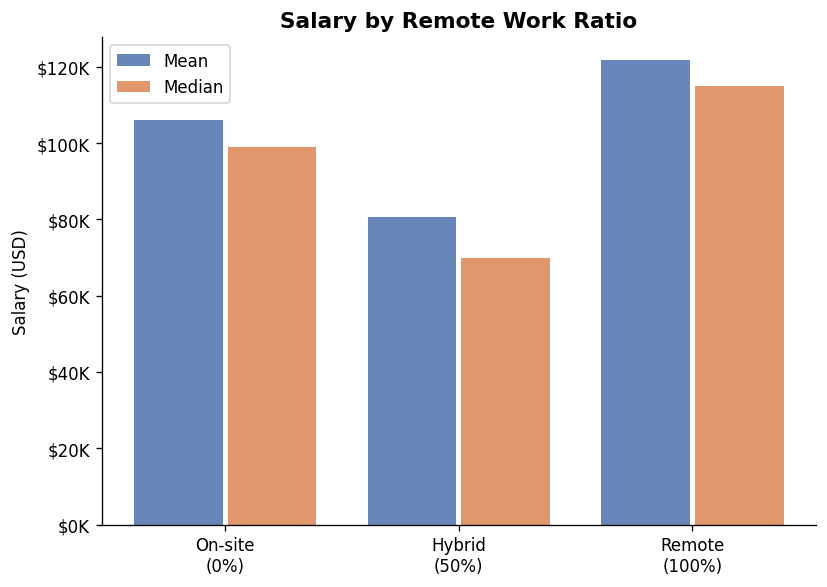

In [22]:
# ── 6.7  Remote ratio vs salary ──────────────────────────────────────────
REMOTE_LABELS = {0: 'On-site\n(0%)', 50: 'Hybrid\n(50%)', 100: 'Remote\n(100%)'}

remote_stats = (df.groupby('remote_ratio')['salary_in_usd']
                  .agg(['mean', 'median']))

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(remote_stats))
ax.bar(x - 0.2, remote_stats['mean'],   0.38, label='Mean',   color=BLUE,  alpha=0.85)
ax.bar(x + 0.2, remote_stats['median'], 0.38, label='Median', color=CORAL, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([REMOTE_LABELS[r] for r in remote_stats.index])
ax.set_title('Salary by Remote Work Ratio')
ax.set_ylabel('Salary (USD)')
usd_fmt(ax)
ax.legend()
plt.tight_layout()
plt.savefig('plots/salary_by_remote_ratio.png', bbox_inches='tight')
plt.show()

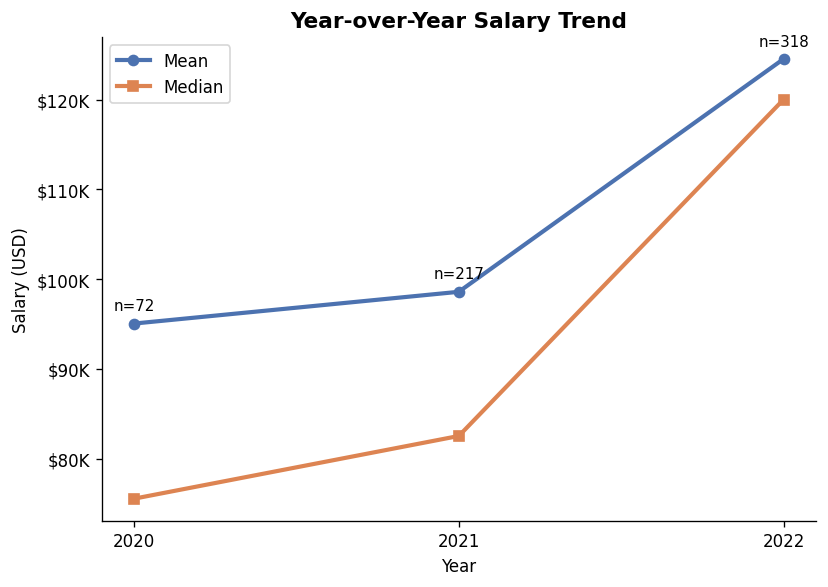

In [23]:
# ── 6.8  Year-over-year salary trend ─────────────────────────────────────
yoy = df.groupby('work_year')['salary_in_usd'].agg(['mean', 'median', 'count'])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(yoy.index, yoy['mean'],   marker='o', label='Mean',   color=BLUE,  lw=2.5)
ax.plot(yoy.index, yoy['median'], marker='s', label='Median', color=CORAL, lw=2.5)
for yr, row in yoy.iterrows():
    ax.annotate(f'n={int(row["count"])}', (yr, row['mean']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
ax.set_title('Year-over-Year Salary Trend')
ax.set_xlabel('Year')
ax.set_ylabel('Salary (USD)')
ax.set_xticks([2020, 2021, 2022])
usd_fmt(ax)
ax.legend()
plt.tight_layout()
plt.savefig('plots/salary_yoy_trend.png', bbox_inches='tight')
plt.show()

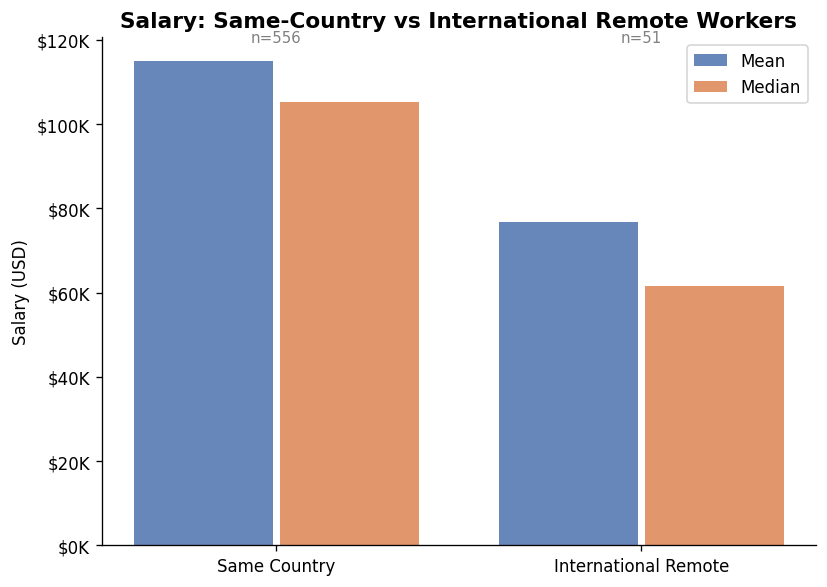

In [24]:
# ── 6.9  International remote vs salary ──────────────────────────────────
intl = df.groupby('is_international_remote')['salary_in_usd'].agg(['mean', 'median', 'count'])
labels = ['Same Country', 'International Remote']

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
ax.bar(x - 0.2, intl['mean'],   0.38, label='Mean',   color=BLUE,  alpha=0.85)
ax.bar(x + 0.2, intl['median'], 0.38, label='Median', color=CORAL, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Salary: Same-Country vs International Remote Workers')
ax.set_ylabel('Salary (USD)')
usd_fmt(ax)
for i, (_, row) in enumerate(intl.iterrows()):
    ax.text(i, intl['mean'].max() * 1.04,
            f'n={int(row["count"])}', ha='center', fontsize=9, color='grey')
ax.legend()
plt.tight_layout()
plt.savefig('plots/salary_international_remote.png', bbox_inches='tight')
plt.show()

## Section 7 — Encoding

| Feature | Strategy | Reason |
|---|---|---|
| `experience_level` | Ordinal (EN=0 → EX=3) | Natural order |
| `company_size` | Ordinal (S=0 → L=2) | Natural order |
| `employment_type` | Label Encode | Low cardinality (4 values) |
| `job_title_bucket` | Label Encode | Low cardinality (5 values) |
| `company_location` | Target Encode | High cardinality — fit on train only |

> **Note:** Target encoding for `company_location` is done **after** the train/test split to prevent data leakage.

In [25]:
# ── Ordinal encoding ─────────────────────────────────────────────────────
EXP_ORD  = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
SIZE_ORD = {'S': 0, 'M': 1, 'L': 2}

df['experience_level'] = df['experience_level'].map(EXP_ORD)
df['company_size']     = df['company_size'].map(SIZE_ORD)

print('experience_level unique values:', sorted(df['experience_level'].unique()))
print('company_size unique values:    ', sorted(df['company_size'].unique()))

# ── Label encoding ───────────────────────────────────────────────────────
le_emp = LabelEncoder()
le_job = LabelEncoder()

df['employment_type']  = le_emp.fit_transform(df['employment_type'])
df['job_title_bucket'] = le_job.fit_transform(df['job_title_bucket'])

print('\nEmployment type mapping:')
print(dict(zip(le_emp.classes_, le_emp.transform(le_emp.classes_))))
print('\nJob title bucket mapping:')
print(dict(zip(le_job.classes_, le_job.transform(le_job.classes_))))

# ── Save encoders ────────────────────────────────────────────────────────
joblib.dump(le_emp,    'models/le_employment_type.pkl')
joblib.dump(le_job,    'models/le_job_title_bucket.pkl')
joblib.dump(EXP_ORD,   'models/ordinal_experience_level.pkl')
joblib.dump(SIZE_ORD,  'models/ordinal_company_size.pkl')
print('\n✅ Encoders saved.')

experience_level unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
company_size unique values:     [np.int64(0), np.int64(1), np.int64(2)]

Employment type mapping:
{'CT': np.int64(0), 'FL': np.int64(1), 'FT': np.int64(2), 'PT': np.int64(3)}

Job title bucket mapping:
{'Data Analyst': np.int64(0), 'Data Engineer': np.int64(1), 'Data Scientist': np.int64(2), 'ML Engineer': np.int64(3), 'Research & Specialized': np.int64(4)}

✅ Encoders saved.


## Section 8 — Log-Transform Target

We apply `log1p` to `salary_in_usd` to normalise the right-skewed distribution.  
At inference time, predictions are inverse-transformed with `expm1`.

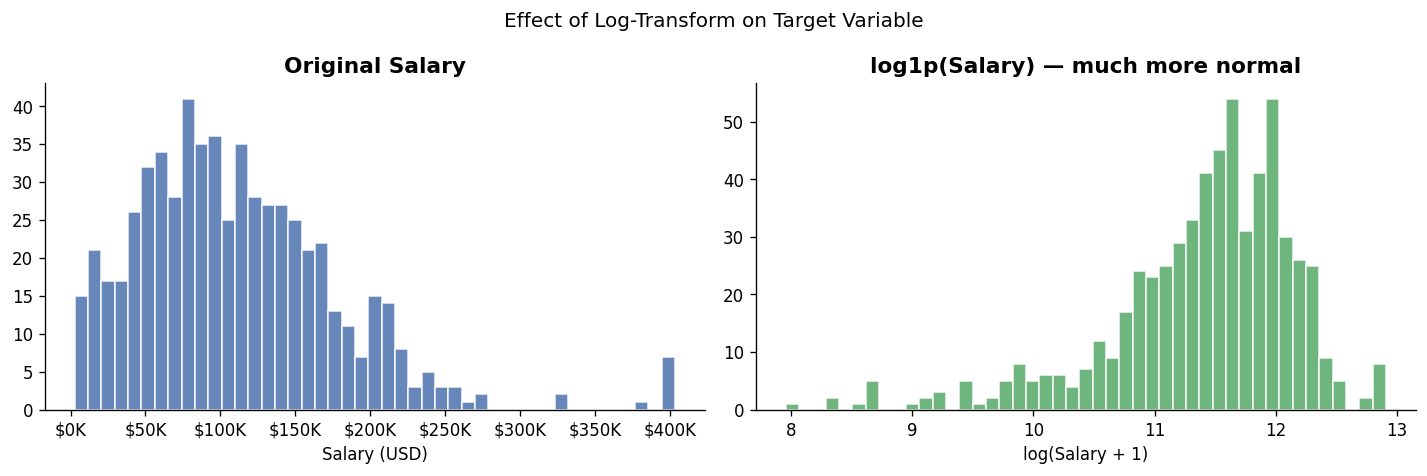

log_salary  →  mean: 11.396  std: 0.772


In [26]:
df['log_salary'] = np.log1p(df['salary_in_usd'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['salary_in_usd'], bins=45, color=BLUE,  edgecolor='white', alpha=0.85)
axes[0].set_title('Original Salary')
axes[0].set_xlabel('Salary (USD)')
usd_fmt(axes[0], 'x')

axes[1].hist(df['log_salary'],    bins=45, color=TEAL,  edgecolor='white', alpha=0.85)
axes[1].set_title('log1p(Salary) — much more normal')
axes[1].set_xlabel('log(Salary + 1)')

fig.suptitle('Effect of Log-Transform on Target Variable', fontsize=12)
plt.tight_layout()
plt.savefig('plots/log_transform_effect.png', bbox_inches='tight')
plt.show()

print(f'log_salary  →  mean: {df["log_salary"].mean():.3f}  std: {df["log_salary"].std():.3f}')

## Section 9 — Train / Test Split

In [27]:
FEATURES = [
    'work_year', 'experience_level', 'employment_type', 'job_title_bucket',
    'remote_ratio', 'company_location', 'company_size', 'is_international_remote'
]
TARGET = 'log_salary'

X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train size: {X_train.shape[0]} rows')
print(f'Test  size: {X_test.shape[0]} rows')

Train size: 485 rows
Test  size: 122 rows


## Section 10 — Target Encoding for `company_location`

Fit **only on training data** to avoid leakage.  
Unknown locations in the test set fall back to the global training mean.

In [28]:
# ── Compute mean log_salary per company_location on TRAIN only ───────────
_tmp = X_train.copy()
_tmp['log_salary'] = y_train.values
loc_target_means = _tmp.groupby('company_location')['log_salary'].mean()

global_mean = y_train.mean()

X_train['company_location'] = X_train['company_location'].map(loc_target_means).fillna(global_mean)
X_test['company_location']  = X_test['company_location'].map(loc_target_means).fillna(global_mean)

# ── Save for inference ────────────────────────────────────────────────────
joblib.dump(loc_target_means, 'models/target_enc_company_location.pkl')
joblib.dump(global_mean,      'models/target_enc_global_mean.pkl')

print('Top 10 company locations by encoded value (mean log salary):')
print(loc_target_means.sort_values(ascending=False).head(10).to_string())
print('\n✅ Target encoding saved.')

Top 10 company locations by encoded value (mean log salary):
company_location
RU    11.848129
US    11.760720
NZ    11.736077
IL    11.687383
AU    11.555734
DZ    11.512935
IQ    11.512935
JP    11.482429
CA    11.430926
SG    11.399701

✅ Target encoding saved.


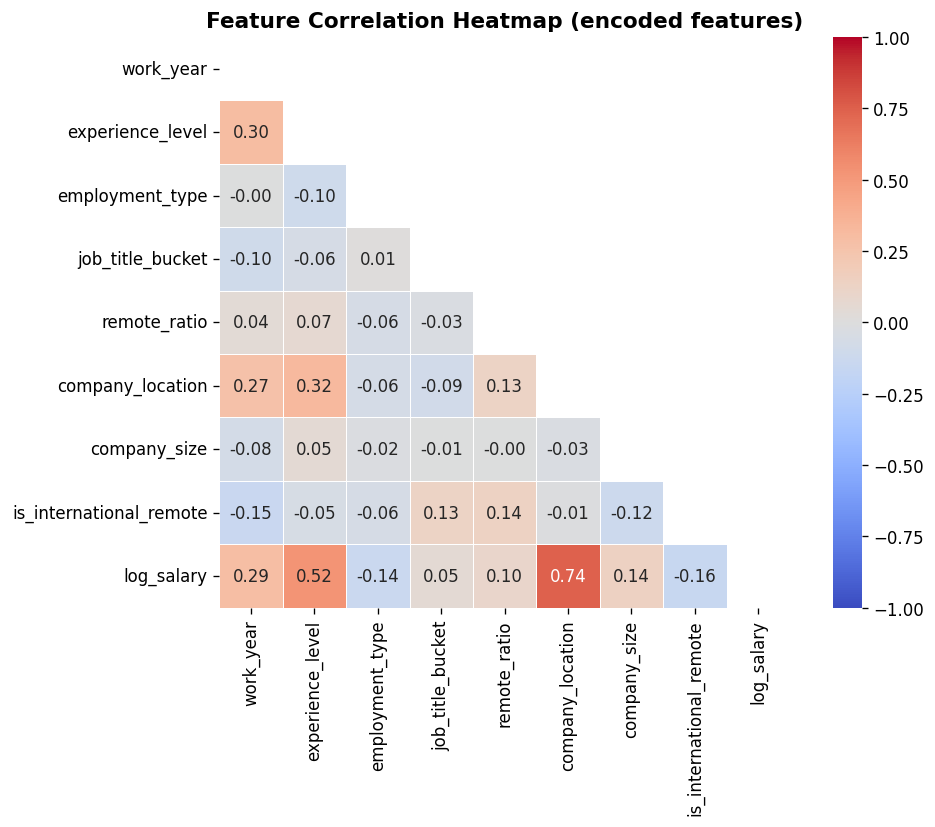

In [29]:
# ── Correlation heatmap — after all encoding ─────────────────────────────
corr_df = X_train.copy()
corr_df['log_salary'] = y_train.values

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(
    corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, ax=ax, square=True, linewidths=0.5,
    vmin=-1, vmax=1
)
ax.set_title('Feature Correlation Heatmap (encoded features)')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Section 11 — Random Forest Training

We use `RandomizedSearchCV` with 5-fold CV to find the best hyperparameters,  
scoring on **negative MAE** in log-space.

In [30]:
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
    'bootstrap':         [True, False],
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rs_cv = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
rs_cv.fit(X_train, y_train)

print(f'\nBest params:')
for k, v in rs_cv.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV MAE (log scale): {-rs_cv.best_score_:.4f}')

best_rf = rs_cv.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best params:
  n_estimators: 200
  min_samples_split: 10
  min_samples_leaf: 2
  max_features: 0.5
  max_depth: 20
  bootstrap: True

Best CV MAE (log scale): 0.3155


## Section 12 — Model Evaluation

In [31]:
y_pred_log = best_rf.predict(X_test)

# ── Inverse transform back to USD ────────────────────────────────────────
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print('=== Model Evaluation — Original USD Scale ===')
print(f'  MAE  : ${mae:>10,.0f}')
print(f'  RMSE : ${rmse:>10,.0f}')
print(f'  R²   : {r2:.4f}')

=== Model Evaluation — Original USD Scale ===
  MAE  : $    26,516
  RMSE : $    40,402
  R²   : 0.5693


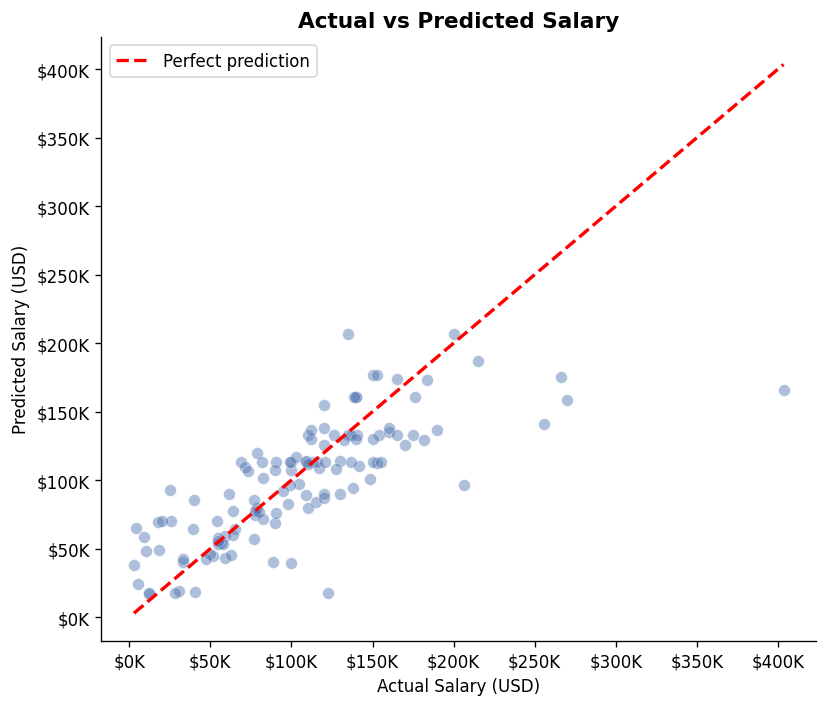

In [32]:
# ── Actual vs Predicted scatter ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_true, y_pred, alpha=0.45, color=BLUE, edgecolors='white', lw=0.4, s=50)
mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
ax.set_title('Actual vs Predicted Salary')
ax.set_xlabel('Actual Salary (USD)')
ax.set_ylabel('Predicted Salary (USD)')
usd_fmt(ax, 'x')
usd_fmt(ax)
ax.legend()
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted.png', bbox_inches='tight')
plt.show()

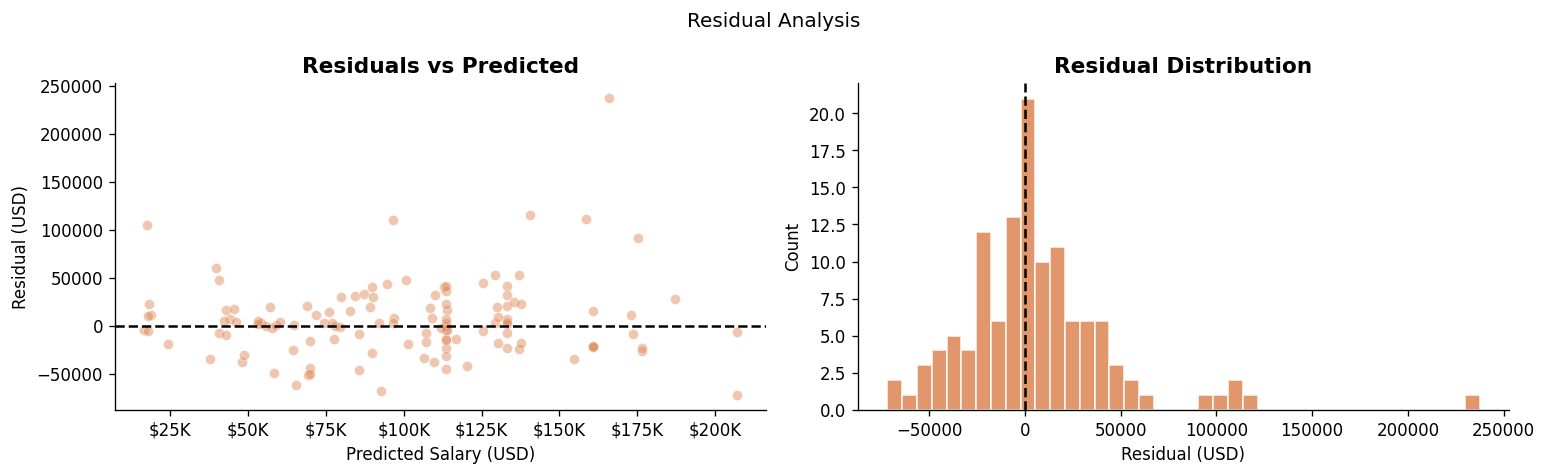

In [33]:
# ── Residuals ─────────────────────────────────────────────────────────────
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred, residuals, alpha=0.45, color=CORAL, edgecolors='white', lw=0.4)
axes[0].axhline(0, color='black', lw=1.5, linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Salary (USD)')
axes[0].set_ylabel('Residual (USD)')
usd_fmt(axes[0], 'x')

axes[1].hist(residuals, bins=40, color=CORAL, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (USD)')
axes[1].set_ylabel('Count')

fig.suptitle('Residual Analysis', fontsize=12)
plt.tight_layout()
plt.savefig('plots/residuals.png', bbox_inches='tight')
plt.show()

## Section 13 — Feature Importance

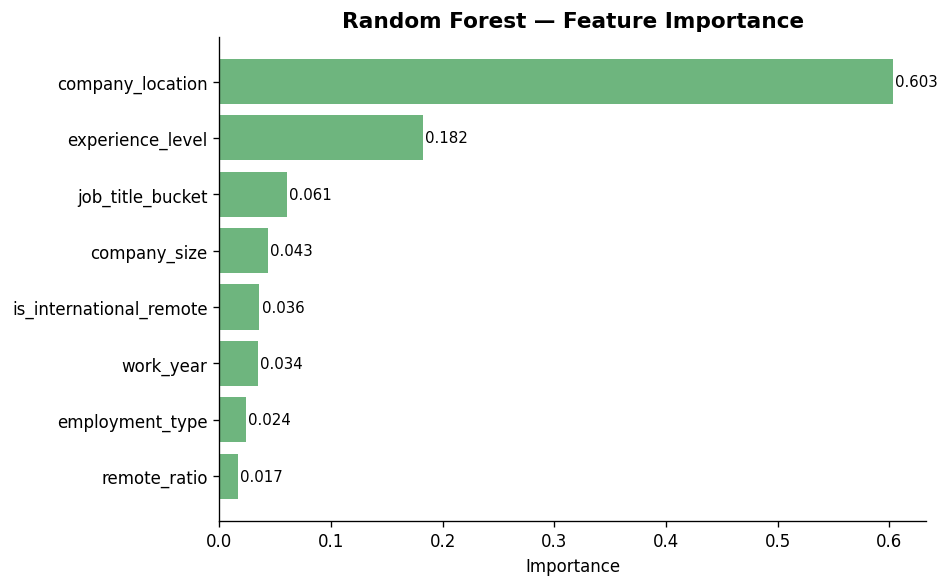

In [34]:
feat_imp = (pd.DataFrame({'feature': X_train.columns,
                          'importance': best_rf.feature_importances_})
              .sort_values('importance', ascending=True))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(feat_imp['feature'], feat_imp['importance'], color=TEAL, alpha=0.85)
ax.set_title('Random Forest — Feature Importance')
ax.set_xlabel('Importance')
for bar, val in zip(bars, feat_imp['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plots/feature_importance.png', bbox_inches='tight')
plt.show()

## Section 14 — Save Model

In [35]:
joblib.dump(best_rf, 'models/random_forest_salary.pkl')
print('✅ Model saved.')
print('\nAll saved artifacts:')
for f in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f}')
    print(f'  models/{f}  ({size/1024:.1f} KB)')

✅ Model saved.

All saved artifacts:
  models/le_employment_type.pkl  (0.5 KB)
  models/le_job_title_bucket.pkl  (0.5 KB)
  models/ordinal_company_size.pkl  (0.0 KB)
  models/ordinal_experience_level.pkl  (0.0 KB)
  models/random_forest_salary.pkl  (1450.7 KB)
  models/target_enc_company_location.pkl  (2.2 KB)
  models/target_enc_global_mean.pkl  (0.1 KB)


In [37]:
import joblib
import numpy as np

# ── Load all individual artifacts ─────────────────────────────────────────
le_emp      = joblib.load('models/le_employment_type.pkl')
le_job      = joblib.load('models/le_job_title_bucket.pkl')
exp_ord     = joblib.load('models/ordinal_experience_level.pkl')
size_ord    = joblib.load('models/ordinal_company_size.pkl')
loc_means   = joblib.load('models/target_enc_company_location.pkl')
global_mean = joblib.load('models/target_enc_global_mean.pkl')
model       = joblib.load('models/random_forest_salary.pkl')

# ── Bundle into one dictionary ────────────────────────────────────────────
pipeline_bundle = {
    'model':                model,
    'le_employment_type':   le_emp,
    'le_job_title_bucket':  le_job,
    'ordinal_exp_level':    exp_ord,
    'ordinal_company_size': size_ord,
    'target_enc_location':  loc_means,
    'target_enc_global':    global_mean,
}

joblib.dump(pipeline_bundle, 'models/salary_pipeline_bundle.joblib')
print('✅ Pipeline bundle saved.')
print(f"Keys: {list(pipeline_bundle.keys())}")

✅ Pipeline bundle saved.
Keys: ['model', 'le_employment_type', 'le_job_title_bucket', 'ordinal_exp_level', 'ordinal_company_size', 'target_enc_location', 'target_enc_global']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')